# Oasis Infobyte Internship — Level 2, Task 01
## Predicting House Prices with Linear Regression

### Objective
The objective of this project is to build and evaluate a Linear Regression model that predicts house prices using property characteristics such as area, number of bedrooms, bathrooms, floors, year built, location, property condition, and garage availability.

### Tools and Libraries
- Python
- Pandas and NumPy
- Matplotlib and Seaborn
- Scikit-learn

### Project Workflow
1. Load and inspect the dataset.
2. Perform exploratory data analysis (EDA).
3. Select suitable features for prediction.
4. Prepare numerical and categorical variables.
5. Split the data into training and testing sets.
6. Train a Linear Regression model.
7. Evaluate model performance using MSE, RMSE, and R².
8. Visualize predictions and residuals.
9. Interpret the model coefficients and summarize the findings.

In [35]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [36]:
# load the dataset
from google.colab import files
uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(filename)
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
display(df.head())

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset (2).csv
Dataset loaded successfully!
Dataset shape: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## 1. Dataset Inspection

The dataset contains house property characteristics and their corresponding prices. The `Price` column is the target variable that the model will predict.

Initial inspection helps us understand the dataset dimensions, column names, data types, and general structure before modelling.

In [37]:
# Dataset inspection
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst five rows:")
display(df.head())
print("\nDataset information:")
df.info()

Number of rows: 2000
Number of columns: 10

Column names:
['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage', 'Price']

Data types:
Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

First five rows:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [38]:
print("Missing values in each column:")
display(df.isnull().sum().to_frame("Missing Values"))
print("Total missing values:", df.isnull().sum().sum())
print("Exact duplicate rows:", df.duplicated().sum())
print("\nUnique values in categorical columns:")
for col in ["Location", "Condition", "Garage"]:
    print(f"{col}: {df[col].unique()}")

Missing values in each column:


,Missing Values
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


Total missing values: 0
Exact duplicate rows: 0

Unique values in categorical columns:
Location: ['Downtown' 'Suburban' 'Urban' 'Rural']
Condition: ['Excellent' 'Good' 'Fair' 'Poor']
Garage: ['No' 'Yes']


### Observation

The uploaded dataset contains 2,000 records and 10 columns. The initial inspection found no missing values and no exact duplicate rows. The dataset includes numerical property characteristics and categorical attributes, which require appropriate preprocessing before Linear Regression.

## 2. Descriptive Statistical Analysis

Descriptive statistics summarize the distribution of numerical variables. The mean, median, standard deviation, minimum, and maximum help us understand the range and variability of the property characteristics and house prices.

In [39]:
# Descriptive statistics
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Id,2000.0,1000.5000,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,2786.2095,1295.146799,501.0,1653.00,2833.0,3887.50,4999.0
Bedrooms,2000.0,3.0035,1.424606,1.0,2.00,3.0,4.00,5.0
Bathrooms,2000.0,2.5525,1.108990,1.0,2.00,3.0,4.00,4.0
Floors,2000.0,1.9935,0.809188,1.0,1.00,2.0,3.00,3.0
YearBuilt,2000.0,1961.4460,35.926695,1900.0,1930.00,1961.0,1993.00,2023.0
Price,2000.0,537676.8550,276428.845719,50005.0,300098.00,539254.0,780086.00,999656.0


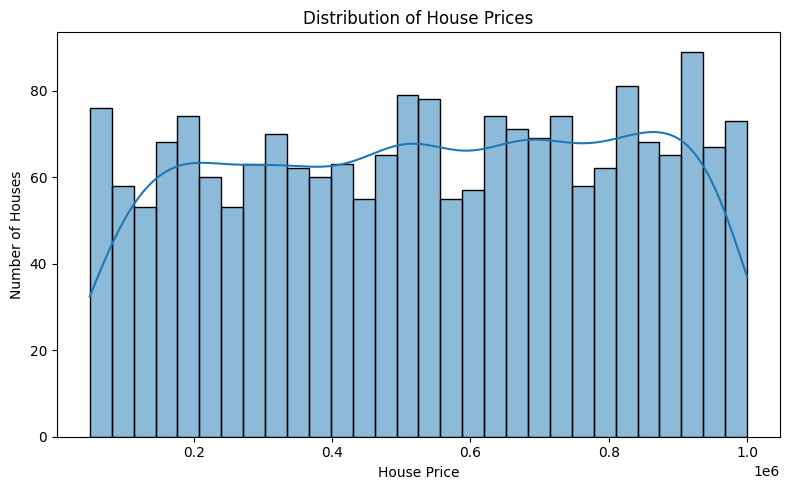

In [40]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

### Observation

The price distribution shows how house prices are spread across the dataset. The descriptive statistics provide information about the typical price, price variability, and minimum and maximum values. The distribution should be examined before interpreting the regression model's predictions.

## 3. Feature Selection

The `Price` column is selected as the target variable because it represents the house price to be predicted.

The following features are selected as potential predictors:

- `Area`: represents the size of the property.
- `Bedrooms`: represents the number of bedrooms.
- `Bathrooms`: represents the number of bathrooms.
- `Floors`: represents the number of floors.
- `YearBuilt`: represents the year in which the property was constructed.
- `Location`: represents the property's geographical category.
- `Condition`: represents the property's condition.
- `Garage`: indicates whether a garage is available.

The `Id` column is excluded because it identifies records rather than describing property characteristics. The selected features will be evaluated using a Linear Regression model.

In [41]:
# Separate features and target
X = df.drop(columns=["Id", "Price"])
y = df["Price"]
print("Feature columns:")
print(X.columns.tolist())
print("\nTarget column: Price")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature columns:
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location', 'Condition', 'Garage']

Target column: Price
Feature shape: (2000, 8)
Target shape: (2000,)


## 4. Correlation Analysis

Correlation measures the strength and direction of a linear relationship between numerical variables. A positive correlation indicates that two variables tend to increase together, while a negative correlation indicates that one tends to decrease as the other increases.

The correlation heatmap is used to inspect relationships among numerical variables. Correlation alone does not establish causation and may not capture nonlinear relationships.

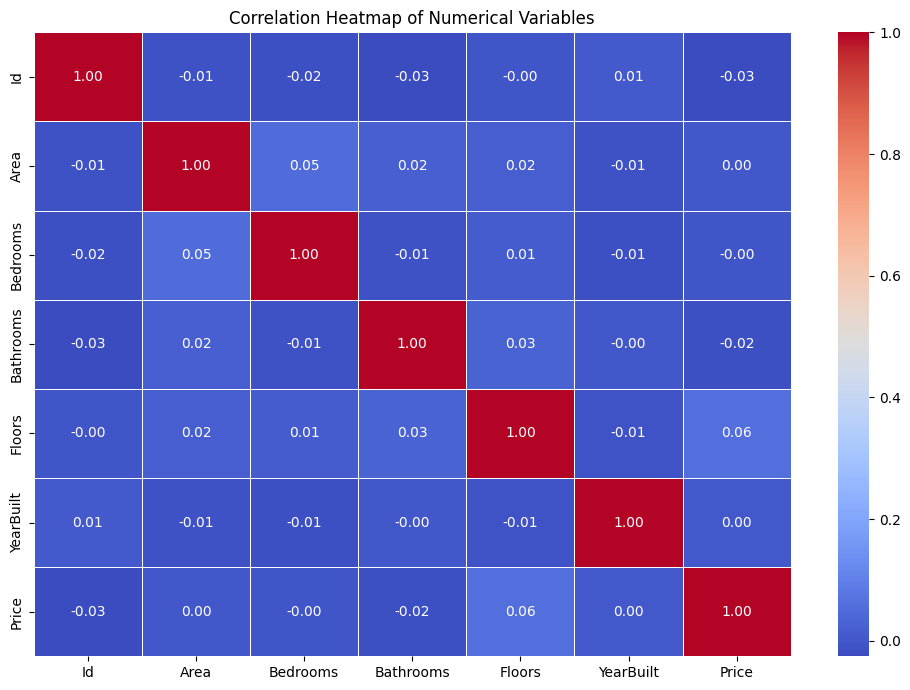

Correlation with Price:


,Correlation with Price
Floors,0.055890
YearBuilt,0.004845
Area,0.001542
Bedrooms,-0.003471
Bathrooms,-0.015737
Id,-0.025643


In [42]:
# Correlation analysis
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()
print("Correlation with Price:")
display(correlation_matrix["Price"].drop("Price").sort_values(ascending=False).to_frame("Correlation with Price"))

### Observation

The heatmap helps identify the strength of linear relationships between numerical features and `Price`. In this uploaded dataset, the numerical correlations with price are very weak. This may limit how accurately a simple Linear Regression model can predict house prices. The model's actual performance will be evaluated rather than assuming that the selected features provide strong predictive information.

## 5. Data Preprocessing

Linear Regression requires numerical input features. The numerical columns are retained as numerical values, while the categorical columns (`Location`, `Condition`, and `Garage`) are converted into numerical indicator columns using One-Hot Encoding.

A preprocessing pipeline is used so that transformations are applied consistently to the training and test datasets. The identifier column is excluded, and the target variable `Price` is kept separate from the predictors.

In [43]:
# Identify numerical and categorical feature columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocess each feature type
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created successfully.")

Numerical features: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
Categorical features: ['Location', 'Condition', 'Garage']

Preprocessing pipeline created successfully.


## 6. Train-Test Split

The dataset is split into 80% training data and 20% testing data. The training set is used to learn the relationship between property characteristics and house prices. The test set is held out to evaluate how well the trained model predicts prices for unseen records.

A fixed random state is used to make the split reproducible.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training target samples:", y_train.shape[0])
print("Testing target samples:", y_test.shape[0])

Training samples: 1600
Testing samples: 400
Training target samples: 1600
Testing target samples: 400


## 7. Linear Regression Model

Linear Regression is a supervised learning algorithm that estimates a linear relationship between input features and a continuous target variable.

The model learns coefficients for the selected features and uses them to estimate house prices. The preprocessing and regression model are combined into one pipeline to avoid applying different transformations to training and test data.

In [45]:
linear_model = Pipeline(steps=[("preprocessor", preprocessor),("regressor", LinearRegression())])

# Train the model
linear_model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [46]:
y_pred = linear_model.predict(X_test)
results = pd.DataFrame({"Actual Price": y_test.values,"Predicted Price": y_pred})
results["Prediction Error"] = (results["Actual Price"] - results["Predicted Price"])
display(results.head(10))

,Actual Price,Predicted Price,Prediction Error
0,514764,521988.221898,-7224.221898
1,694256,549119.311967,145136.688033
2,66375,487101.222356,-420726.222356
3,650243,539752.743993,110490.256007
4,223285,553242.248725,-329957.248725
5,468127,521375.920258,-53248.920258
6,513002,523320.180806,-10318.180806
7,911525,578133.643533,333391.356467
8,723265,545899.647385,177365.352615
9,339416,577368.699406,-237952.699406


## 8. Model Evaluation

The model is evaluated using three metrics:

- **Mean Squared Error (MSE):** The average squared difference between actual and predicted prices. Lower values indicate smaller squared errors.
- **Root Mean Squared Error (RMSE):** The square root of MSE. It is expressed in the same units as the house price.
- **R² Score:** Measures how much variation in the target is explained by the model relative to predicting the mean of the test targets. A value closer to 1 is generally better; a negative value means the model performs worse than the mean-prediction baseline on the test data.

These metrics are calculated on the held-out test set.

In [47]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
evaluation = pd.DataFrame({"Metric": ["MSE", "RMSE", "MAE", "R² Score"],"Value": [mse, rmse, mae, r2]})
display(evaluation)
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"R² Score: {r2:.4f}")

,Metric,Value
0,MSE,7.832147e+10
1,RMSE,2.798597e+05
2,MAE,2.432420e+05
3,R² Score,-6.717808e-03


Mean Squared Error (MSE): 78,321,466,146.03
Root Mean Squared Error (RMSE): 279,859.73
Mean Absolute Error (MAE): 243,241.98
R² Score: -0.0067


### Interpretation of Evaluation Metrics

MSE and RMSE describe the magnitude of prediction errors, while R² indicates how well the model explains variation in house prices.

The values printed above should be used to assess this model. A low or negative R² would indicate that the selected features do not explain the price variation well. A good-looking prediction plot alone is not sufficient to claim strong model performance.

## 9. Actual vs. Predicted Prices

The scatter plot compares actual house prices with the model's predictions. The dashed diagonal line represents perfect predictions, where predicted prices equal actual prices.

Points closer to this line indicate more accurate predictions. Large deviations from the line indicate prediction errors.

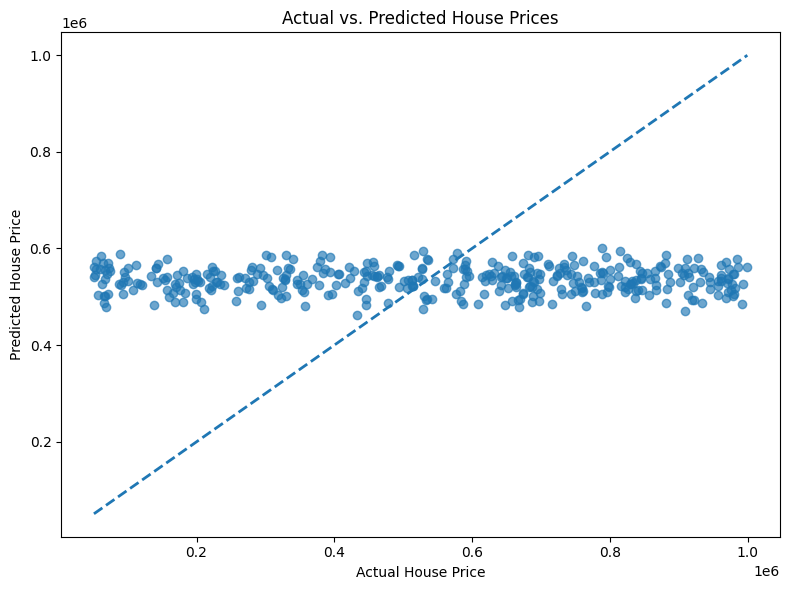

In [48]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.65)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs. Predicted House Prices")
plt.tight_layout()
plt.show()

### Observation

The scatter plot shows how closely the predictions follow the ideal diagonal line. The degree of spread around this line indicates prediction error. This visualization should be interpreted together with the test-set metrics, especially RMSE and R².

## 10. Residual Analysis

A residual is the difference between an actual value and its predicted value:

Residual = Actual Price − Predicted Price.

A residual plot helps identify patterns in prediction errors. Ideally, residuals are distributed around zero without a clear systematic pattern. Curved patterns or changing spread may suggest that a linear model does not fully capture the data relationships.

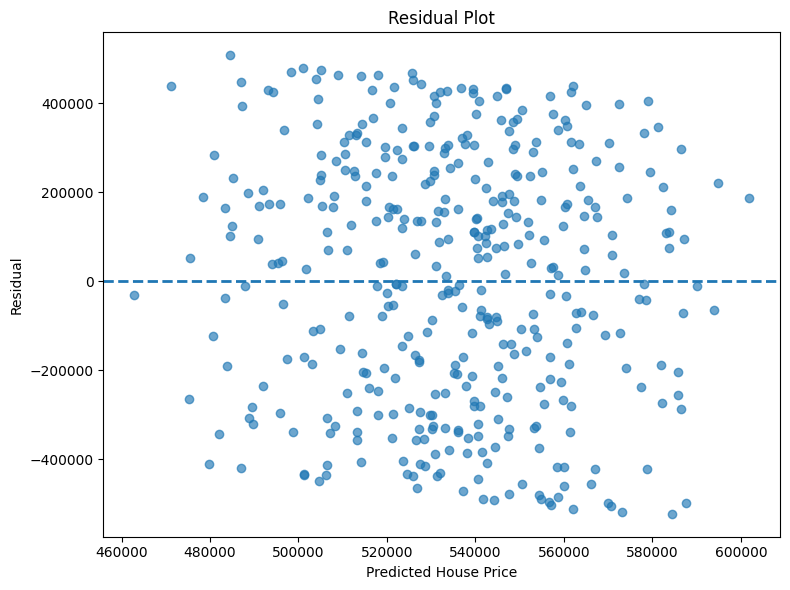

In [49]:
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.65)
plt.axhline(y=0, linestyle="--", linewidth=2)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

### Observation

The residual plot is used to check whether errors are randomly distributed around zero. Any visible patterns or large residuals may indicate that the model has difficulty representing the underlying relationship between property characteristics and price.

## 11. Model Coefficient Analysis

Linear Regression assigns a coefficient to each transformed feature. A positive coefficient indicates that an increase in that feature is associated with a higher predicted price, while a negative coefficient indicates a lower predicted price, holding the other model features constant.

For One-Hot Encoded categorical variables, coefficients are interpreted relative to the omitted reference category. Coefficients describe the fitted model and should not automatically be interpreted as causal effects.

,Feature,Coefficient,Absolute Coefficient
3,num__Floors,23727.983633,23727.983633
10,cat__Condition_Fair,20279.424861,20279.424861
11,cat__Condition_Good,-16744.927821,16744.927821
8,cat__Location_Urban,-12746.572142,12746.572142
7,cat__Location_Suburban,11484.336584,11484.336584
2,num__Bathrooms,-9662.248234,9662.248234
9,cat__Condition_Excellent,-3803.882985,3803.882985
6,cat__Location_Rural,1289.888789,1289.888789
13,cat__Garage_No,-1186.765289,1186.765289
14,cat__Garage_Yes,1186.765289,1186.765289


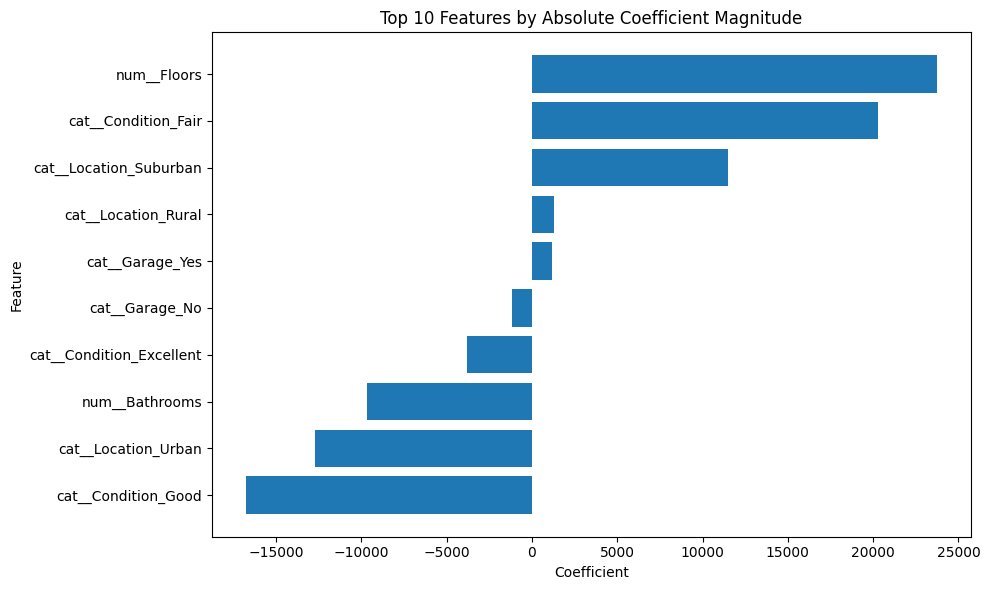

In [50]:
# Extract transformed feature names
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["regressor"].coef_
coefficient_df = pd.DataFrame({"Feature": feature_names,"Coefficient": coefficients})
coefficient_df["Absolute Coefficient"] = (coefficient_df["Coefficient"].abs())
coefficient_df = coefficient_df.sort_values("Absolute Coefficient",ascending=False)
display(coefficient_df)

# Plot the 10 largest coefficients by absolute magnitude
top_coefficients = coefficient_df.head(10).sort_values("Coefficient")
plt.figure(figsize=(10, 6))
plt.barh(top_coefficients["Feature"],top_coefficients["Coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Features by Absolute Coefficient Magnitude")
plt.tight_layout()
plt.show()

### Interpretation

The coefficient table identifies which features have the largest fitted coefficients in the model. Positive and negative coefficients indicate the direction of association in the fitted regression equation.

Because numerical features and categorical indicator variables have different scales and meanings, coefficient magnitudes should be interpreted carefully. The weak numerical correlations observed earlier also suggest that coefficient values alone may not establish useful predictive relationships.

## 12. Bonus: Ridge Regression Comparison

Ridge Regression is a regularized linear model that penalizes large coefficients. It can help reduce overfitting when features are correlated or when the fitted coefficients are unstable.

Both models are evaluated on the same test set using the same preprocessing and split. The comparison helps determine whether regularization improves predictive performance on this dataset.

In [51]:
ridge_model = Pipeline(steps=[("preprocessor", preprocessor),("regressor", Ridge(alpha=1.0))])
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mean_squared_error(y_test, y_pred),mean_squared_error(y_test, ridge_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred)),np.sqrt(mean_squared_error(y_test, ridge_pred))],
    "MAE": [mean_absolute_error(y_test, y_pred),mean_absolute_error(y_test, ridge_pred)],
    "R2 Score": [r2_score(y_test, y_pred),r2_score(y_test, ridge_pred)]
})
display(model_comparison)

,Model,MSE,RMSE,MAE,R2 Score
0,Linear Regression,7.832147e+10,279859.725838,243241.977588,-0.006718
1,Ridge Regression,7.832107e+10,279859.011634,243243.244979,-0.006713


### Model Comparison

Compare the test-set RMSE, MAE, and R² scores for Linear Regression and Ridge Regression. Lower RMSE and MAE indicate smaller errors, while a higher R² indicates better explanatory performance relative to the test-set mean baseline.

The best model should be identified using the actual evaluation results, not by assuming that Ridge Regression or Linear Regression will always perform better.

### Model Limitations

The Linear Regression model achieved a test R² score of approximately -0.0067, indicating that it performed slightly worse than a baseline that predicts the mean test-set price. The RMSE was approximately 279,859.73 and the MAE was approximately 243,241.98 in the dataset's price units.

The weak relationships between the available features and house prices may explain the limited predictive performance. The results should be reported honestly; a higher score should not be assumed or artificially created. Further work could investigate data quality, additional predictive features, and alternative modelling approaches.

## 13. Conclusion

This project used the uploaded house-price dataset to develop and evaluate a Linear Regression model. The workflow included data inspection, descriptive statistics, exploratory visualization, feature selection, categorical encoding, an 80/20 train-test split, model training, and evaluation.

Model performance was assessed using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the R² score. Actual-versus-predicted and residual plots were used to inspect prediction quality, while coefficient analysis examined the direction and magnitude of the fitted relationships.

The initial correlation analysis showed that numerical features have very weak linear correlations with `Price`. Therefore, the model may have limited predictive performance. The final evaluation metrics should be used to report how well the model performs on unseen data. If performance is poor, this may reflect weak relationships in the dataset rather than an implementation error.

The project demonstrates an end-to-end regression workflow and highlights the importance of evaluating data quality and predictive signal before using a model for real-world house-price estimation.